# GSEP Mapping Analysis

This notebook analyzes Gas System Enhancement Program (GSEP) investments in Massachusetts,
examining their overlap with equity-focused regions:

- **Environmental Justice Communities (EJC)**
- **Low-to-Moderate Income (LMI) areas**
- **Gateway Cities**

## Setup

In [1]:
# Install dependencies if needed (uncomment if running in Colab)
# !pip install contextily geopandas

In [2]:
import matplotlib.pyplot as plt

from src import (
    load_gsep_projects,
    load_ejc_data,
    load_lmi_data,
    load_gateway_cities,
    load_national_grid_feeders,
    load_code_communities,
    load_fossil_fuel_free_communities,
    load_climate_leader_communities,
    compute_point_overlap,
    compute_line_length_in_region,
    add_equity_region_flags,
    compute_equity_overlap_counts,
    plot_overlay_map,
    plot_overlap_bar_chart,
    plot_equity_heatmap,
    plot_equity_overlap_histogram,
    plot_code_communities_map,
)

## Load Data

Data is automatically cached after the first download.

In [3]:
# Load GSEP projects (downloads from ArcGIS if not cached)
gsep_df = load_gsep_projects()
print(f"Loaded {len(gsep_df)} GSEP projects")

GSEP data already cached. Loading from disk...
Loaded Eversource: 398 records
Loaded Liberty: 292 records
Loaded Berkshire: 34 records
Loaded Eversource: 1445 records
Loaded Berkshire: 37 records
Loaded National Grid: 1238 records
Loaded Unitil: 230 records
Loaded National Grid: 100 records
Total GSEP records: 3774
Loaded 3774 GSEP projects


/workspaces/gsep_mapping/src/data_loader.py:206: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gsep_df = pd.concat(dfs, ignore_index=True)


In [4]:
# Load equity region layers
ejc_df = load_ejc_data()
lmi_df = load_lmi_data()
gateway_df = load_gateway_cities()
national_grid_df = load_national_grid_feeders()

Loading EJC data...
LMI data cached. Loading from disk...
Loading Gateway Cities data...
Loading National Grid feeder data...
Loaded 4168 feeder segments (373 NWA opportunities)


## GSEP Analysis: Environmental Justice Communities

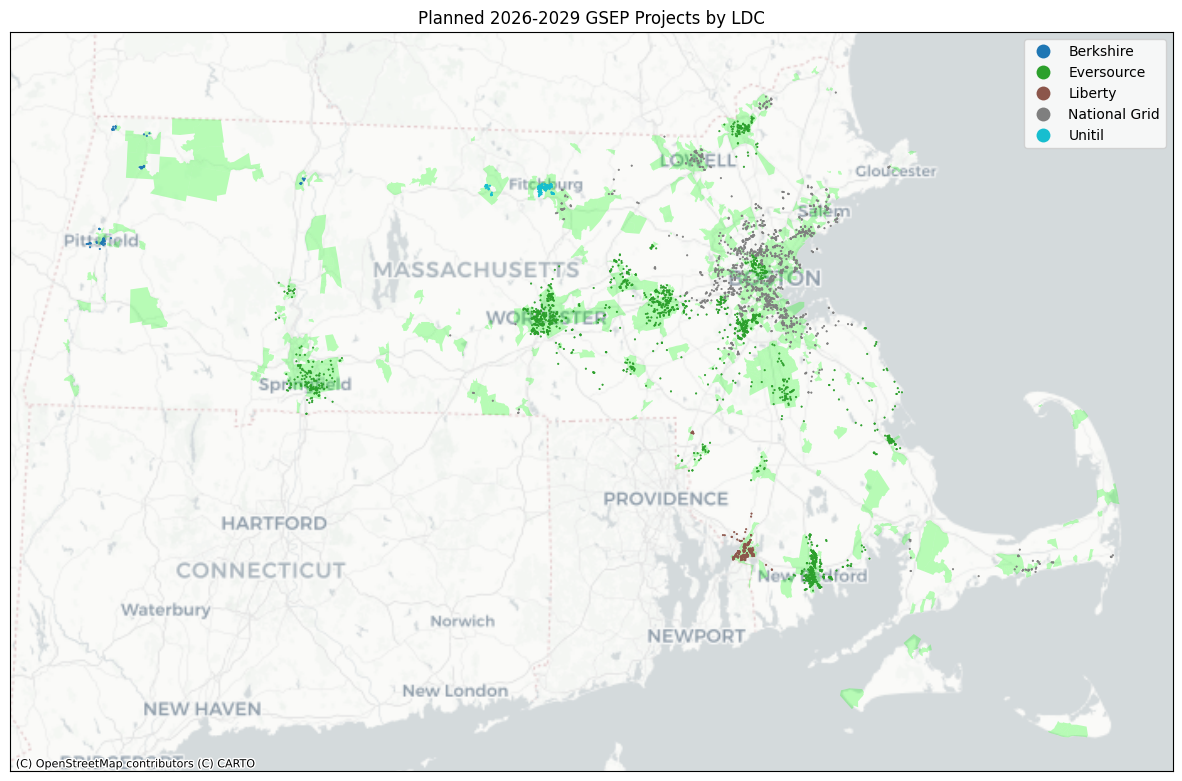

In [5]:
# Map GSEP projects with EJC overlay
plot_overlay_map(
    ejc_df,
    gsep_df,
    title="Planned 2026-2029 GSEP Projects by LDC",
    region_color="#00ff0044",
    region_label="EJCs",
    overlay_column="LDC",
)
plt.show()

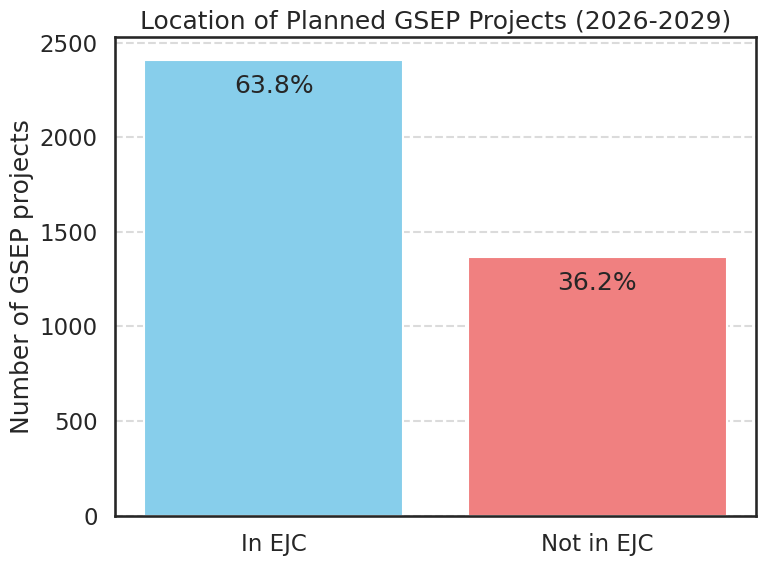

In [6]:
# Compute and plot EJC overlap
gsep_df, ejc_stats = compute_point_overlap(gsep_df, ejc_df, "EJC")
plot_overlap_bar_chart(
    ejc_stats,
    title="Location of Planned GSEP Projects (2026-2029)",
    ylabel="Number of GSEP projects",
)
plt.show()

## GSEP Analysis: Low-to-Moderate Income Areas

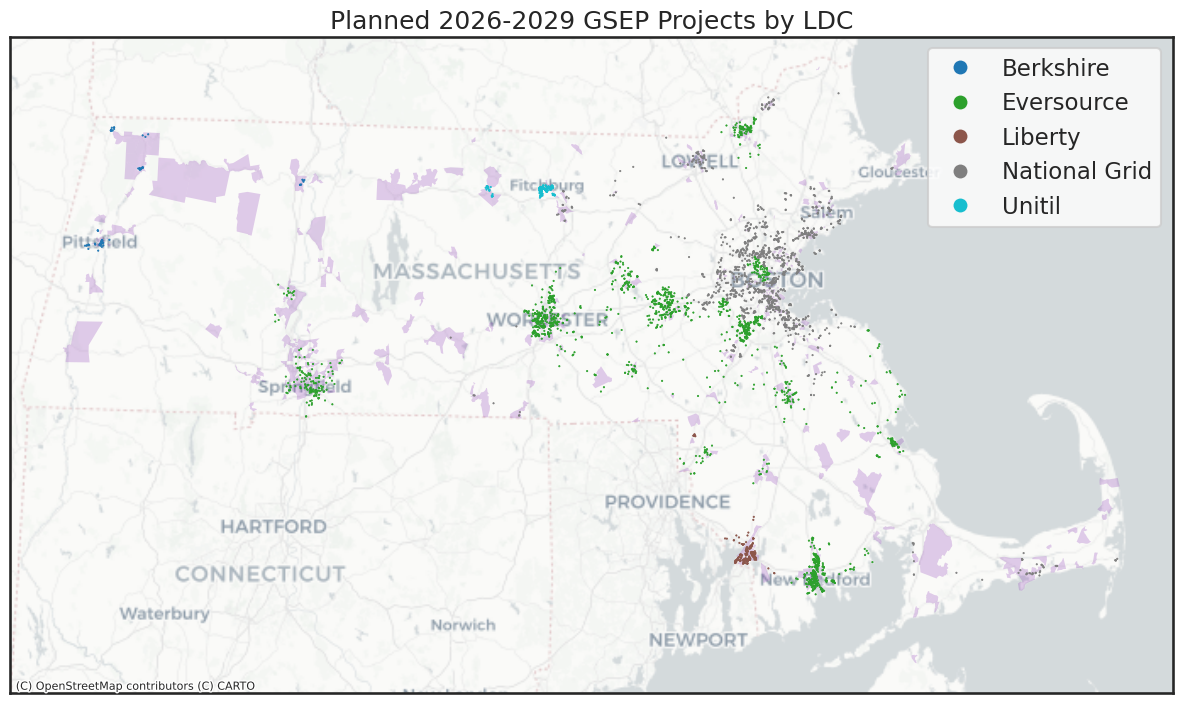

In [7]:
# Filter LMI data to only LMI block groups
lmi_only = lmi_df[lmi_df["is_lmi"]]

# Map GSEP with LMI overlay
plot_overlay_map(
    lmi_only,
    gsep_df,
    title="Planned 2026-2029 GSEP Projects by LDC",
    region_color="#9448BC44",
    region_label="LMI Census Block Groups",
    overlay_column="LDC",
)
plt.show()

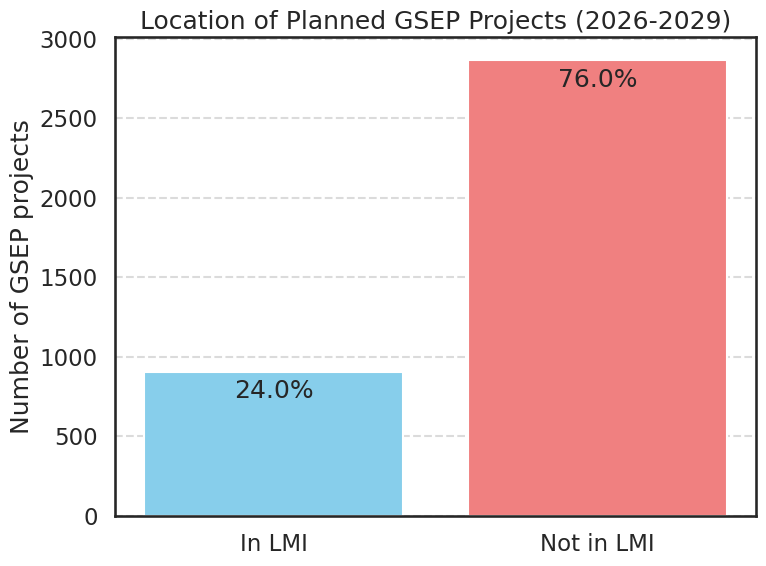

In [8]:
# Compute and plot LMI overlap
gsep_df, lmi_stats = compute_point_overlap(gsep_df, lmi_only, "LMI")
plot_overlap_bar_chart(
    lmi_stats,
    title="Location of Planned GSEP Projects (2026-2029)",
    ylabel="Number of GSEP projects",
)
plt.show()

## GSEP Analysis: Gateway Cities

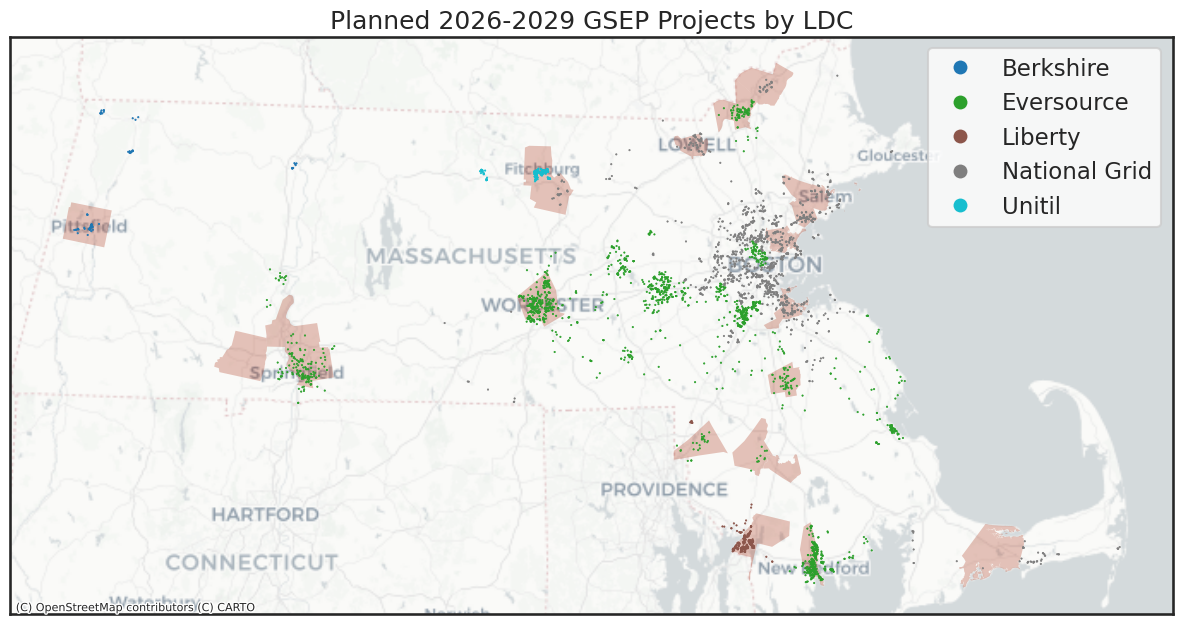

In [9]:
# Map GSEP with Gateway Cities overlay
plot_overlay_map(
    gateway_df,
    gsep_df,
    title="Planned 2026-2029 GSEP Projects by LDC",
    region_color="#a7260844",
    region_label="Gateway Cities",
    overlay_column="LDC",
)
plt.show()

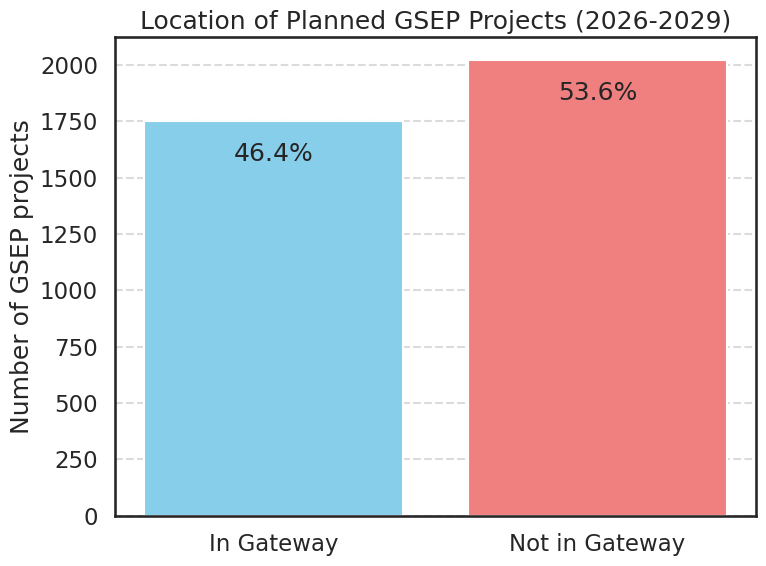

In [10]:
# Compute and plot Gateway Cities overlap
gsep_df, gateway_stats = compute_point_overlap(gsep_df, gateway_df, "Gateway")
plot_overlap_bar_chart(
    gateway_stats,
    title="Location of Planned GSEP Projects (2026-2029)",
    ylabel="Number of GSEP projects",
)
plt.show()

## National Grid NWA Opportunities Analysis

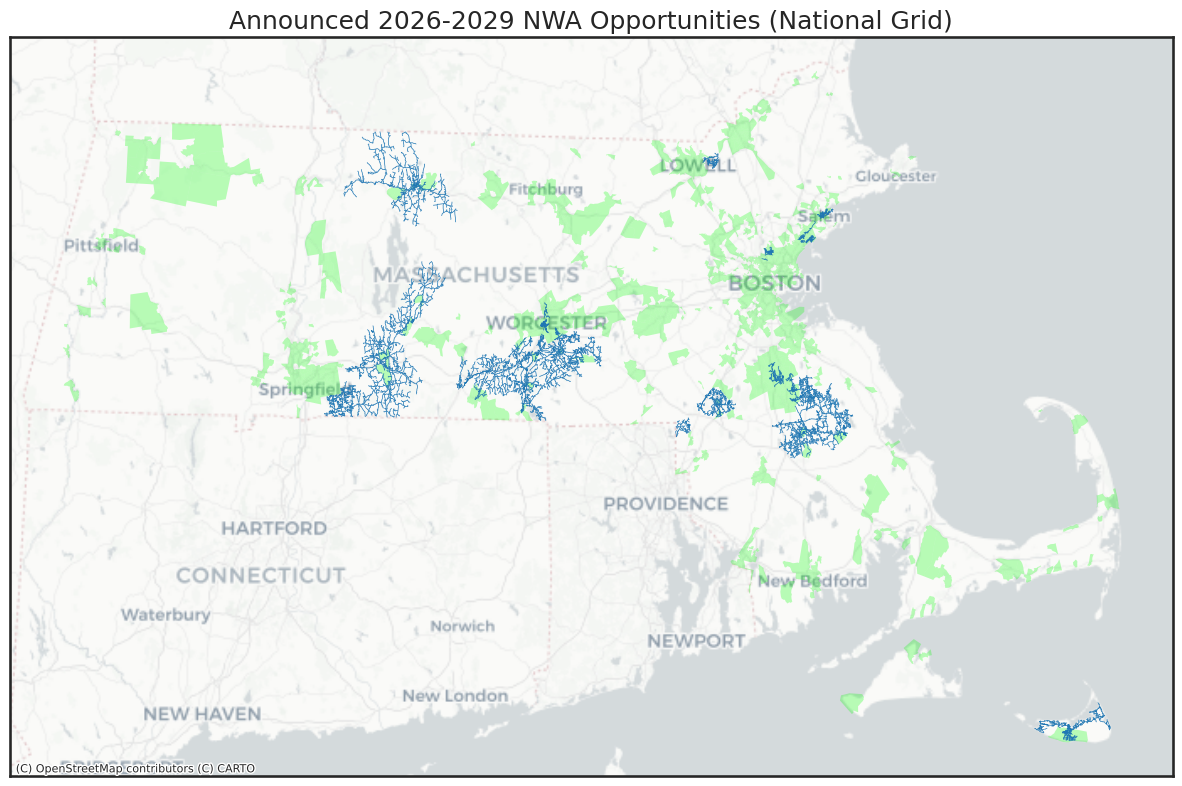

In [11]:
# Map NWA opportunities with EJC overlay
plot_overlay_map(
    ejc_df,
    national_grid_df,
    title="Announced 2026-2029 NWA Opportunities (National Grid)",
    region_color="#00ff0044",
    region_label="EJCs",
    overlay_filter_col="nwa_opportunity",
    show_legend=False,
)
plt.show()

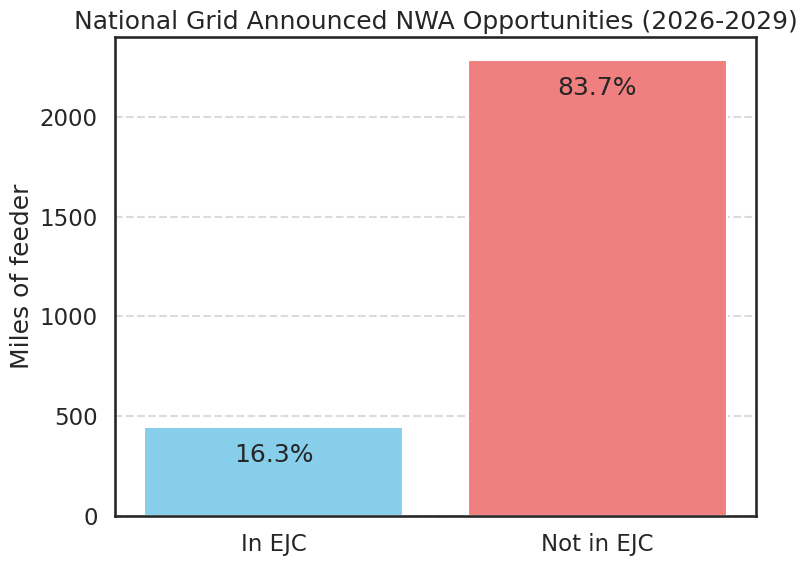

In [12]:
# Compute NWA feeder length in EJCs
national_grid_df, ejc_length_stats = compute_line_length_in_region(
    national_grid_df, ejc_df, "EJC", filter_col="nwa_opportunity", filter_value=True
)
plot_overlap_bar_chart(
    ejc_length_stats,
    title="National Grid Announced NWA Opportunities (2026-2029)",
    ylabel="Miles of feeder",
)
plt.show()

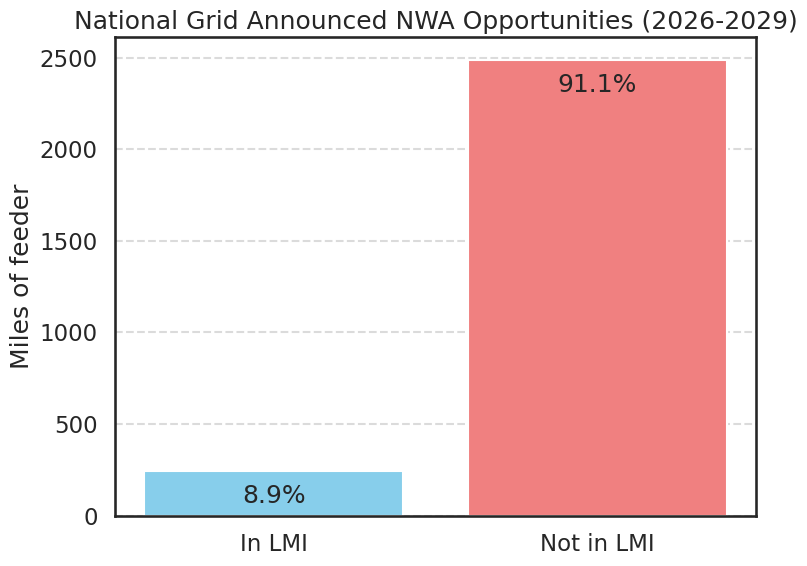

In [13]:
# Compute NWA feeder length in LMI areas
national_grid_df, lmi_length_stats = compute_line_length_in_region(
    national_grid_df, lmi_only, "LMI", filter_col="nwa_opportunity", filter_value=True
)
plot_overlap_bar_chart(
    lmi_length_stats,
    title="National Grid Announced NWA Opportunities (2026-2029)",
    ylabel="Miles of feeder",
)
plt.show()

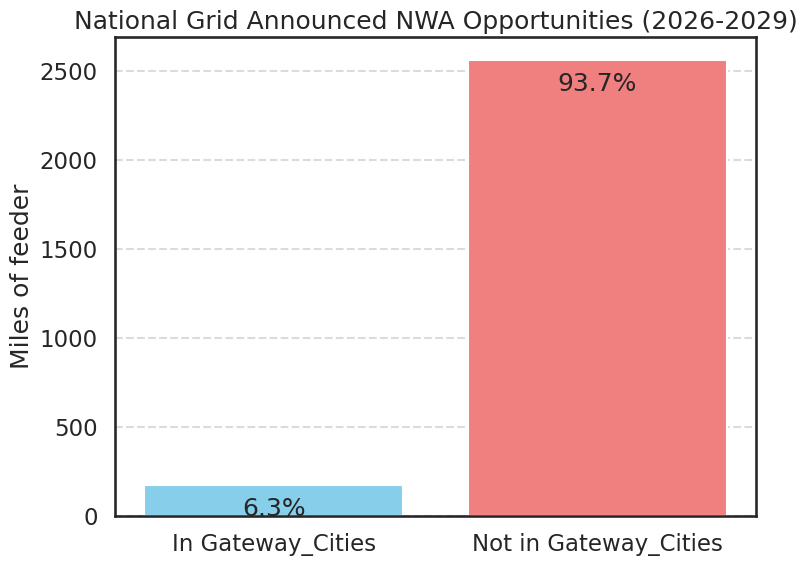

In [14]:
# Compute NWA feeder length in Gateway Cities
national_grid_df, gateway_length_stats = compute_line_length_in_region(
    national_grid_df,
    gateway_df,
    "Gateway_Cities",
    filter_col="nwa_opportunity",
    filter_value=True,
)
plot_overlap_bar_chart(
    gateway_length_stats,
    title="National Grid Announced NWA Opportunities (2026-2029)",
    ylabel="Miles of feeder",
)
plt.show()

## Combined Equity Analysis

Analyze GSEP projects by how many equity regions they overlap with.

In [15]:
# Add all equity region flags
equity_layers = {
    "EJC": ejc_df,
    "LMI": lmi_only,
    "Gateway": gateway_df,
}
gsep_df = add_equity_region_flags(gsep_df, equity_layers)

# Count overlaps
flag_cols = ["is_in_ejc", "is_in_lmi", "is_in_gateway"]
gsep_df["equity_region_overlaps"] = compute_equity_overlap_counts(gsep_df, flag_cols)

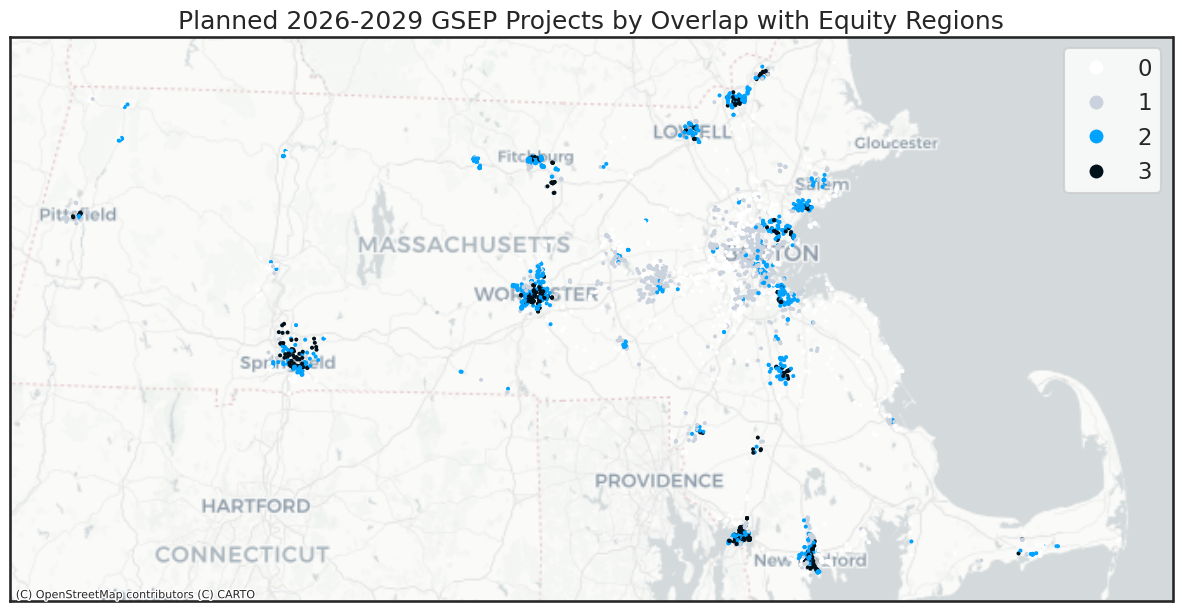

In [16]:
# Heatmap of equity region overlaps
plot_equity_heatmap(
    gsep_df,
    "equity_region_overlaps",
    title="Planned 2026-2029 GSEP Projects by Overlap with Equity Regions",
)
plt.show()

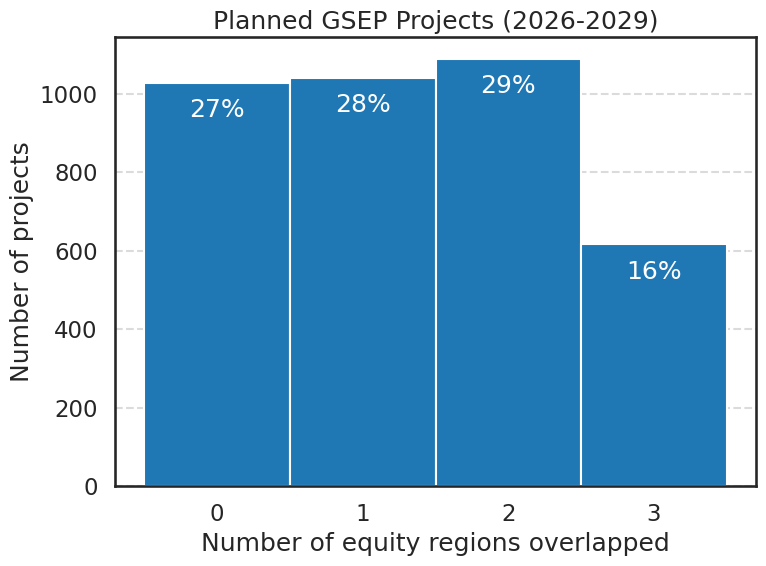

In [17]:
# Histogram of equity region overlaps
plot_equity_overlap_histogram(
    gsep_df,
    "equity_region_overlaps",
    title="Planned GSEP Projects (2026-2029)",
)
plt.show()

## GSEP Analysis: Code Communities

Massachusetts municipalities are classified by their building energy code adoption:
- **Base Code**: Standard energy code (50 municipalities)
- **Stretch Code**: More stringent energy efficiency requirements (189 municipalities)
- **Specialized Code**: Most stringent requirements, includes electrification provisions (56 municipalities)

In [18]:
code_communities_df = load_code_communities()

Loading code communities data...


Loaded 351 municipalities:
  - Base: 50
  - Stretch: 245
  - Specialized: 56


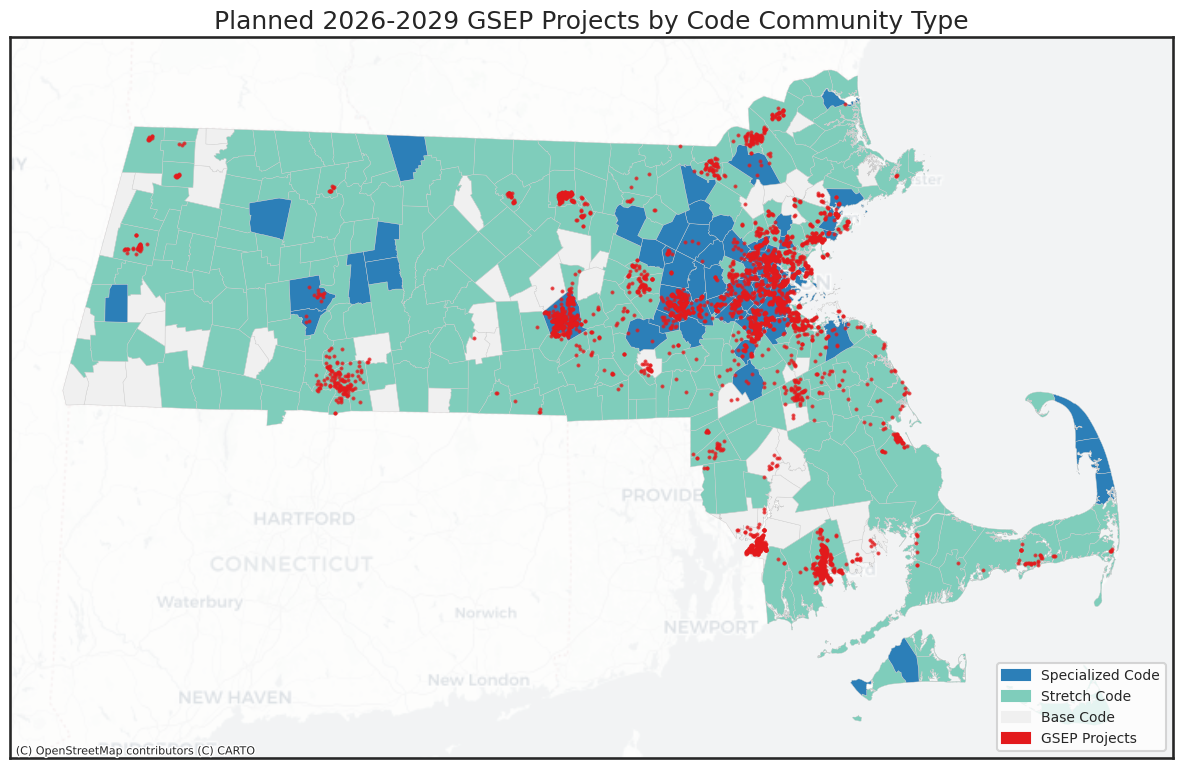

In [19]:
# Map GSEP projects overlaid on code communities
plot_code_communities_map(
    code_communities_df,
    gsep_df,
    title="Planned 2026-2029 GSEP Projects by Code Community Type",
)
plt.show()

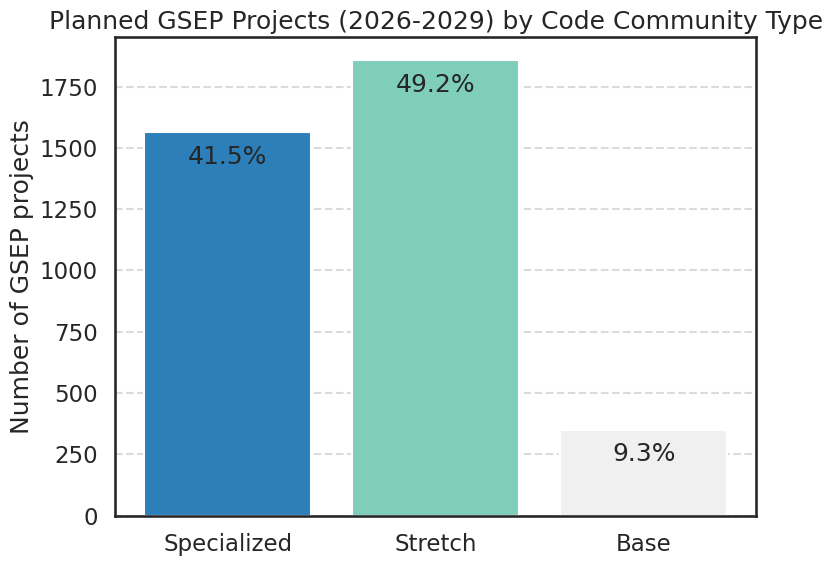

In [20]:
# Compute GSEP projects in each code community type
from geopandas import sjoin

# Spatial join GSEP projects to code communities
gsep_proj = gsep_df.to_crs(code_communities_df.crs)
gsep_with_code = sjoin(
    gsep_proj,
    code_communities_df[["code_type", "geometry"]],
    how="left",
    predicate="within",
)

# Count projects by code type
code_counts = gsep_with_code["code_type"].value_counts()
# Ensure all categories are present
for cat in ["Specialized", "Stretch", "Base"]:
    if cat not in code_counts.index:
        code_counts[cat] = 0
code_counts = code_counts[["Specialized", "Stretch", "Base"]]

# Plot bar chart
plot_overlap_bar_chart(
    code_counts,
    title="Planned GSEP Projects (2026-2029) by Code Community Type",
    ylabel="Number of GSEP projects",
    colors=["#2C7FB8", "#7FCDBB", "#F0F0F0"],
    percentage_offset=-150,
)
plt.show()

## GSEP Analysis: Fossil Fuel Free Communities

Some Massachusetts municipalities have adopted fossil fuel free policies restricting new fossil fuel infrastructure in buildings.

In [21]:
# Load fossil fuel free communities data
fff_df = load_fossil_fuel_free_communities()
fff_only = fff_df[fff_df["is_fossil_fuel_free"]]

Loading fossil fuel free communities data...


Loaded 351 municipalities:
  - Fossil Fuel Free: 10
  - Other: 341


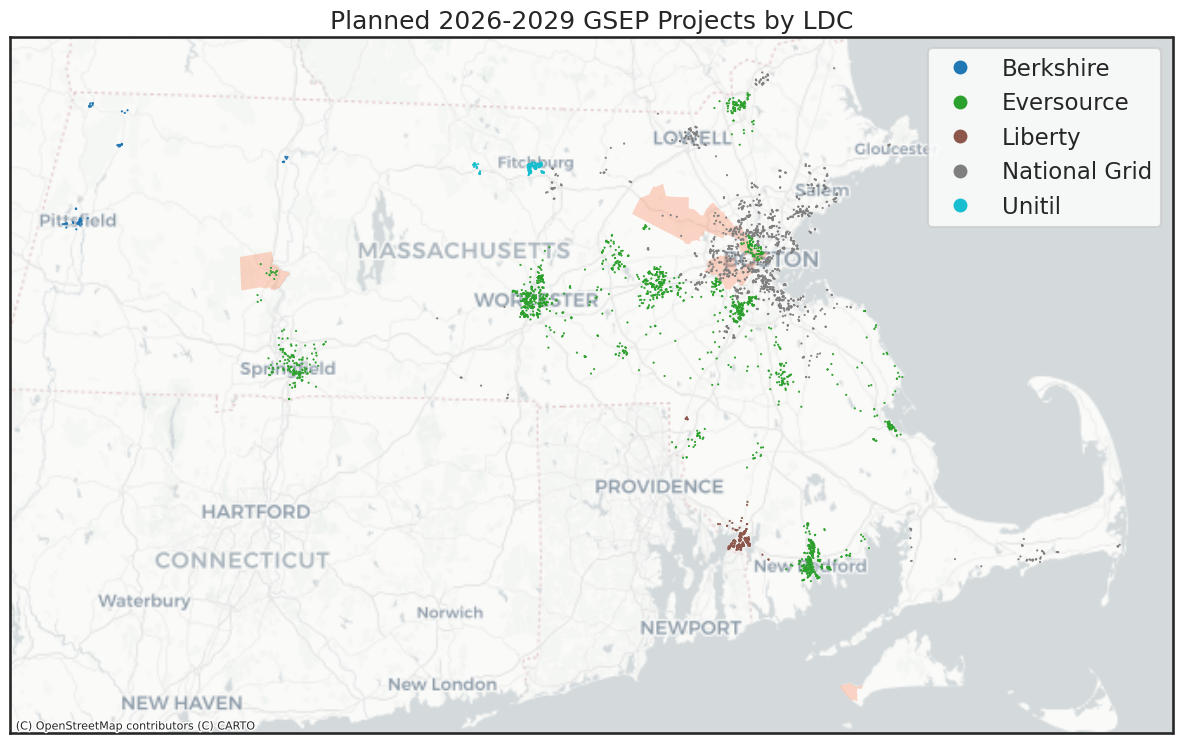

In [22]:
# Map GSEP projects with Fossil Fuel Free overlay
plot_overlay_map(
    fff_only,
    gsep_df,
    title="Planned 2026-2029 GSEP Projects by LDC",
    region_color="#FF6B3544",
    region_label="Fossil Fuel Free Communities",
    overlay_column="LDC",
)
plt.show()

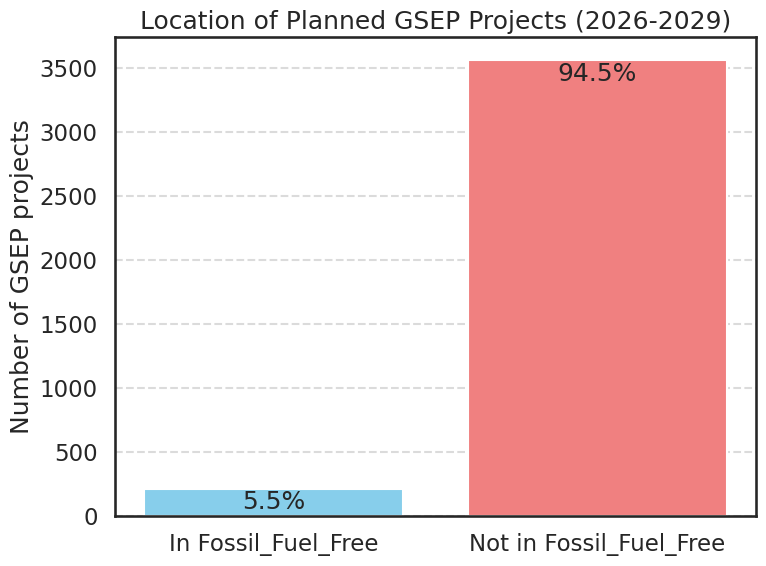

In [23]:
# Compute and plot Fossil Fuel Free overlap
gsep_df, fff_stats = compute_point_overlap(gsep_df, fff_only, "Fossil_Fuel_Free")
plot_overlap_bar_chart(
    fff_stats,
    title="Location of Planned GSEP Projects (2026-2029)",
    ylabel="Number of GSEP projects",
)
plt.show()

## GSEP Analysis: Climate Leader Communities

Climate Leader Communities are Massachusetts municipalities that have demonstrated leadership in climate action and clean energy adoption.

In [24]:
# Load climate leader communities data
cl_df = load_climate_leader_communities()
cl_only = cl_df[cl_df["is_climate_leader"]]

Loading climate leader communities data...
Loaded 351 municipalities:
  - Climate Leader: 28
  - Other: 323


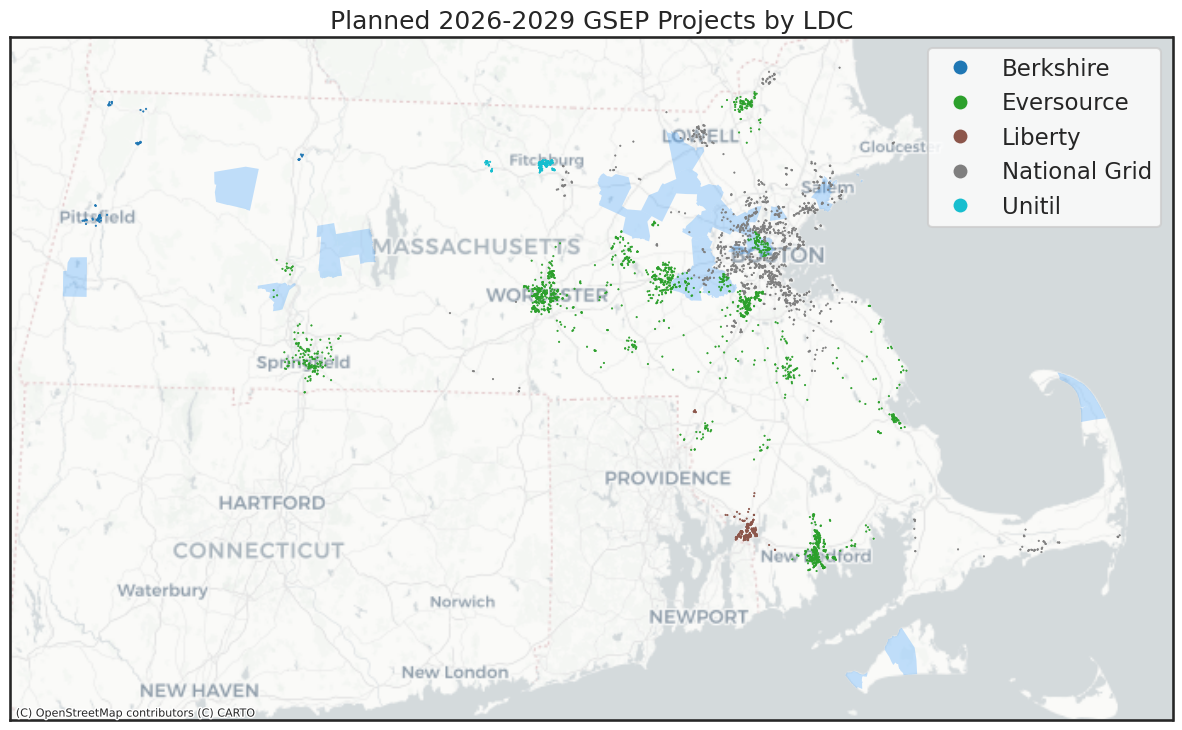

In [25]:
# Map GSEP projects with Climate Leader overlay
plot_overlay_map(
    cl_only,
    gsep_df,
    title="Planned 2026-2029 GSEP Projects by LDC",
    region_color="#1E90FF44",
    region_label="Climate Leader Communities",
    overlay_column="LDC",
)
plt.show()

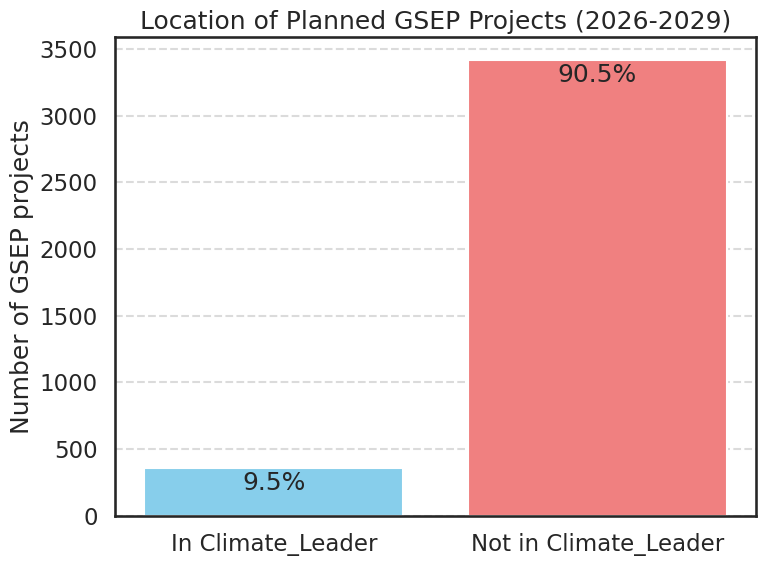

In [26]:
# Compute and plot Climate Leader overlap
gsep_df, cl_stats = compute_point_overlap(gsep_df, cl_only, "Climate_Leader")
plot_overlap_bar_chart(
    cl_stats,
    title="Location of Planned GSEP Projects (2026-2029)",
    ylabel="Number of GSEP projects",
)
plt.show()

## Adding New Layers

The system is designed to be easily extensible. To add a new data layer:

1. Place the GeoJSON/shapefile in `data/raw/`
2. Add a loader function in `src/data_loader.py`
3. Use the existing analysis functions:

```python
# Example: Adding a new "Opportunity Zone" layer
from src import load_opportunity_zones, compute_point_overlap

oz_df = load_opportunity_zones()
gsep_df, oz_stats = compute_point_overlap(gsep_df, oz_df, "Opportunity Zone")
plot_overlap_bar_chart(oz_stats, title="GSEP in Opportunity Zones")
```